# Atividade: GANs

Neste notebook, você irá **preparar seu próprio dataset** e **treinar uma DCGAN utilizando a distância de Wasserstein**.
O objetivo é gerar imagens sintéticas a partir de ruído, aprendendo a distribuição dos dados reais.

O treinamento será realizado com um **Gerador** e um **Crítico** (substituindo o discriminador tradicional), aplicando **gradient clipping** para garantir a restrição de Lipschitz exigida pela métrica de Wasserstein.

Ao final, o modelo deverá ser capaz de **produzir imagens realistas** a partir de vetores aleatórios.

## Preparando os dados

Para esta atividade, será necessário baixar ou montar um dataset de imagens de um domínio específico (por exemplo, rostos, paisagens, objetos, etc.). Você pode utilizar datasets públicos como LFW e CelebA ou criar o seu próprio conjunto de imagens armazenadas em uma pasta local.

### Coleta de Imagens

Caso opte por montar seu próprio dataset, você pode utilizar a biblioteca iCrawler para baixar imagens automaticamente a partir de buscadores (como Google, Bing ou Baidu), fornecendo uma lista de termos relacionados ao domínio desejado.

In [2]:
#import os
#from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

#def download_images(keyword, folder, n_total=100):
  #  os.makedirs(folder, exist_ok=True)
   # downloaded = len(os.listdir(folder))
    #remaining = n_total - downloaded

   # while downloaded < n_total:
    #    crawler = GoogleImageCrawler(storage={'root_dir': folder})
    #    crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
    #    downloaded = len(os.listdir(folder))
    #    remaining = n_total - downloaded
    #    print(f"Downloaded {downloaded}/{n_total}")

#    print("Download complete!")

In [3]:
# download_images("darth vader", f"data/vader", n_total=200)

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Dataset_Gatos/CAT_00",
    labels=None,               # sem rótulos
    image_size=(224, 224),     # tamanho desejado
    batch_size=32
)


Found 1706 files.


### Implementação do Dataset

Com as imagens já disponíveis, implemente uma **classe de Dataset personalizada** para o PyTorch. Ela deve herdar de `Dataset` e retornar, em cada amostra, a imagem processada pelos **transforms** definidos anteriormente.

O Dataset deve:

* Ler as imagens a partir de uma pasta.
* Converter as imagens para **tensor normalizado** (ex.: valores entre -1 e 1).

In [6]:
# ================================
# Dataset personalizado em PyTorch
# ================================

from PIL import Image
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ----------- TRANSFORMAÇÕES -----------
# Redimensiona, converte para tensor e normaliza para [-1,1]
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# ----------- CLASSE DATASET -----------
class ImageDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


# ----------- CARREGANDO O DATASET -----------
folder_path = "/content/drive/MyDrive/Dataset_Gatos/CAT_00"

dataset = ImageDataset(folder=folder_path, transform=transform)

# ----------- DATALOADER -----------
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Teste rápido: exibir formato do primeiro batch
batch = next(iter(train_loader))
print("Formato do batch:", batch.shape)  # deve ser [32, 3, 224, 224]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Formato do batch: torch.Size([64, 3, 64, 64])


### Carregamento

Carregue os dados a partir do seu dataset de imagens e aplique os transforms necessários. Caso o dataset seja pequeno, recomenda-se o uso de data augmentation (como flips horizontais, jitter de cor ou pequenas rotações) para aumentar a diversidade das amostras e melhorar a estabilidade do treinamento adversarial. Em seguida, defina um batch size adequado e instancie um DataLoader.

In [7]:
#

## Definição dos Modelos

Para este exercício, deverão ser utilizadas DCGANs com distância de Wasserstein. Nesta seção, defina a arquitetura dos modelos Gerador e Crítico, implementando o treinamento adversarial baseado na métrica de Wasserstein.

### Gerador

O Gerador seguirá a arquitetura típica de uma DCGAN, produzindo amostras sintéticas a partir de vetores de ruído, enquanto o Crítico avaliará a distância entre as distribuições reais e geradas.

In [8]:
import torch
import torch.nn as nn

# Tamanho do vetor de ruído (padrão DCGAN)
z_dim = 100

# Gerador estilo DCGAN
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # Entrada: Z (100) → 1024 × 4 × 4
            nn.ConvTranspose2d(z_dim, features_g * 8, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            # 1024 → 512 × 8 × 8
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            # 512 → 256 × 16 × 16
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            # 256 → 128 × 32 × 32
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            # 128 → 3 × 64 × 64
            nn.ConvTranspose2d(features_g, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # saída entre -1 e 1
        )

    def forward(self, x):
        return self.net(x)


# Instancia o Gerador
gen = Generator(z_dim=z_dim).to("cuda" if torch.cuda.is_available() else "cpu")

print(gen)


Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)


### Crítico

O Crítico (substituindo o discriminador tradicional) deve utilizar gradient clipping para garantir o cumprimento da restrição de Lipschitz, condição essencial para a estabilidade da função de custo de Wasserstein.

In [9]:
import torch
import torch.nn as nn

# Critico estilo DCGAN, mas sem BatchNorm (regra da WGAN)
class Critic(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super(Critic, self).__init__()

        self.net = nn.Sequential(
            # Entrada: 3 × 64 × 64 → 64 × 32 × 32
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 → 128 × 16 × 16
            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 → 256 × 8 × 8
            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 → 512 × 4 × 4
            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Saída: 512 → 1 × 1 × 1
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0)
            # Sem sigmoid! WGAN usa valor bruto
        )

    def forward(self, x):
        return self.net(x)


# Instancia o Critico
critic = Critic().to("cuda" if torch.cuda.is_available() else "cpu")

print(critic)


Critic(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
  )
)


## Treinamento

Com o **Gerador** e o **Crítico** definidos, e os dados devidamente carregados, inicie o treinamento.

Durante o processo:

* Atualize o **Crítico** várias vezes para cada atualização do **Gerador**, garantindo uma estimativa mais precisa da distância de Wasserstein.
* Aplique **gradient clipping** nos parâmetros do Crítico após cada atualização, mantendo a restrição de **Lipschitz**.
* Utilize **losses baseadas na métrica de Wasserstein**.

Ao longo do treinamento, **visualize amostras geradas** a cada determinado número de épocas, observando a evolução da qualidade das imagens produzidas pelo Gerador.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# ====== Hiperparâmetros ======
lr = 1e-4
z_dim = 100
batch_size = 32          # menor = mais rápido
epochs = 100              # suficiente pra ver forma de gato aparecer
critic_iterations = 1    # otimizado p/ velocidade
lambda_gp = 10
sample_dir = "samples_wgan_gp"

os.makedirs(sample_dir, exist_ok=True)

# ====== Instanciar modelos ======
gen = Generator(z_dim=z_dim).to(device)
critic = Critic().to(device)

# ====== Otimizadores (Adam ideal para WGAN-GP) ======
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=lr, betas=(0.0, 0.9))


# ====== Gradient Penalty ======
def gradient_penalty(critic, real, fake):
    batch_size, C, H, W = real.shape
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real)

    interpolated = real * alpha + fake * (1 - alpha)
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    grads = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grads = grads.view(grads.size(0), -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp


# ====== Gerar amostra ======
def gerar_amostra(epoch):
    with torch.no_grad():
        noise = torch.randn(32, z_dim, 1, 1, device=device)
        fake = gen(noise)
        fake = (fake + 1) / 2   # [-1,1] → [0,1]

        caminho = f"{sample_dir}/epoch_{epoch+1}.png"
        save_image(fake, caminho, nrow=8)
        print(f">>> Amostra salva em: {caminho}")


# ====== Loop de treinamento ======
for epoch in range(epochs):
    for batch_idx, real in enumerate(train_loader):
        real = real.to(device)
        cur_batch_size = real.size(0)

        # ----- Treino do CRÍTICO -----
        for _ in range(critic_iterations):
            noise = torch.randn(cur_batch_size, z_dim, 1, 1, device=device)
            fake = gen(noise)

            critic_real = critic(real).mean()
            critic_fake = critic(fake.detach()).mean()

            gp = gradient_penalty(critic, real, fake)
            loss_critic = -(critic_real - critic_fake) + lambda_gp * gp

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        # ----- Treino do GERADOR -----
        noise = torch.randn(cur_batch_size, z_dim, 1, 1, device=device)
        fake = gen(noise)
        critic_fake = critic(fake).mean()

        loss_gen = -critic_fake

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        # Logs
        if batch_idx % 50 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}]  Batch {batch_idx}/{len(train_loader)}  "
                f"Loss Critic: {loss_critic:.4f}  Loss Gen: {loss_gen:.4f}"
            )

    if (epoch + 1) % 10 == 0:
        gerar_amostra(epoch)

print("\nTreinamento WGAN-GP finalizado!")


Epoch [1/100]  Batch 0/27  Loss Critic: 9.7092  Loss Gen: 0.0375
Epoch [2/100]  Batch 0/27  Loss Critic: -44.7384  Loss Gen: 47.2704
Epoch [3/100]  Batch 0/27  Loss Critic: -29.3114  Loss Gen: 18.6525
Epoch [4/100]  Batch 0/27  Loss Critic: -8.6227  Loss Gen: 7.9164
Epoch [5/100]  Batch 0/27  Loss Critic: -6.3271  Loss Gen: -34.6565
Epoch [6/100]  Batch 0/27  Loss Critic: -6.3119  Loss Gen: -23.2276
Epoch [7/100]  Batch 0/27  Loss Critic: -9.4272  Loss Gen: -7.7276
Epoch [8/100]  Batch 0/27  Loss Critic: -0.9240  Loss Gen: -38.9396
Epoch [9/100]  Batch 0/27  Loss Critic: -0.4621  Loss Gen: -23.8961
Epoch [10/100]  Batch 0/27  Loss Critic: -4.2367  Loss Gen: -35.5233
>>> Amostra salva em: samples_wgan_gp/epoch_10.png
Epoch [11/100]  Batch 0/27  Loss Critic: -4.8398  Loss Gen: -13.2415
Epoch [12/100]  Batch 0/27  Loss Critic: -3.5939  Loss Gen: -20.9990
Epoch [13/100]  Batch 0/27  Loss Critic: -7.0189  Loss Gen: -31.1859
Epoch [14/100]  Batch 0/27  Loss Critic: -3.6496  Loss Gen: -18.963

## Inferência

Após o treinamento, utilize o **Gerador** para produzir novas imagens a partir de **vetores de ruído aleatório**.
Cada vetor servirá como ponto de partida no espaço latente, sendo transformado pelo modelo em uma amostra sintética do domínio aprendido.

Durante a inferência:

* Gere múltiplas imagens e visualize os resultados.
* Analise a **qualidade e diversidade** das amostras produzidas.

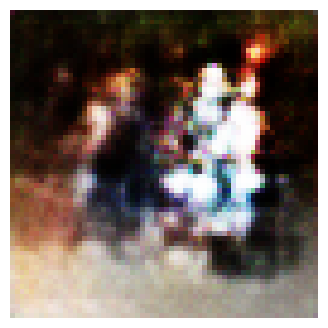

In [11]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Número de imagens a gerar
num_images = 8
z_dim = 100

# Ruído aleatório
noise = torch.randn(num_images, z_dim, 1, 1).to(device)

# Geração (com o modelo já treinado)
with torch.no_grad():
    fake_images = gen(noise)
    fake_images = (fake_images * 0.5) + 0.5  # normaliza para [0,1]

# Mostrar apenas a última imagem gerada
img = fake_images[-1].permute(1, 2, 0).cpu()
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()
